# SkyGuard AI — Exploratory Data Analysis & Geospatial Verification

**Project Objective:** Automated Quality Control (QA/QC) & AI-powered anomaly detection for India's Automatic Weather Station (AWS) network.  
**Core Sensor Variables:**
1. **Temperature (°C)**
2. **Air Pressure (mbar)**
3. **Relative Humidity (%)**

**Key EDA Goals:**
- Audit dataset health, completeness, and missing values.
- **Geospatial EDA:** Map all 826 AWS stations across India, evaluate topographical elevations, and compute nearest-neighbor spatial proximity.
- **Sensor Physics EDA:** Verify thermodynamic correlations (Temp vs. RH, Barometric Pressure vs. Elevation, Diurnal Cycles).
- **Anomaly Precursors:** Establish empirical rate-of-change thresholds (spikes, flatlines) for the AI anomaly detector.

## 1. Environment Setup & Data Ingestion

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# 1. Load Complete Station Registry (826 stations across all 36 States & UTs)
stations_file = "complete_all_india_aws_stations.csv"
stations_df = pd.read_csv(stations_file)
print(f"[+] Master Station Registry: {len(stations_df)} stations across {stations_df['state'].nunique()} States & UTs")

# 2. Load Weather Observations (Loads sample or full dataset if available)
weather_file = "aws_weather_data_all_india_2023_present.csv" if os.path.exists("aws_weather_data_all_india_2023_present.csv") else "sample_aws_weather_data.csv"
weather_df = pd.read_csv(weather_file, parse_dates=['timestamp'])
print(f"[+] Weather Observations Loaded ({weather_file}): {len(weather_df):,} rows")

display(stations_df.head(5))
display(weather_df.head(5))

[+] Master Station Registry: 826 stations across 36 States & UTs
[+] Weather Observations Loaded (sample_aws_weather_data.csv): 87,600 rows


,station_id,station_name,state,district,latitude,longitude,elevation_m
0,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0
1,IMD_AWS_0008,Eluru,Andhra Pradesh,Eluru,16.7107,81.0952,22.0
2,IMD_AWS_0007,East Godavari (Rajahmundry),Andhra Pradesh,Rajahmundry,17.0005,81.8040,14.0
3,IMD_AWS_0003,Annamayya (Rayachoti),Andhra Pradesh,Rayachoti,14.0560,78.7520,380.0
4,IMD_AWS_0010,Kakinada,Andhra Pradesh,Kakinada,16.9891,82.2475,2.0


,station_id,station_name,state,district,latitude,longitude,elevation_m,timestamp,temperature_c,air_pressure_mbar,relative_humidity_pct
0,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0,2023-01-01 00:00:00,23.0,1011.0,96
1,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0,2023-01-01 01:00:00,22.5,1010.5,98
2,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0,2023-01-01 02:00:00,22.1,1010.1,98
3,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0,2023-01-01 03:00:00,22.6,1010.0,98
4,IMD_AWS_0009,Guntur,Andhra Pradesh,Guntur,16.3067,80.4365,33.0,2023-01-01 04:00:00,21.8,1010.3,100


## 2. Geospatial EDA & Station Network Topology

In AWS anomaly detection, **spatial consistency** is vital. If a sensor reports an abrupt change, we cross-validate it against **neighboring AWS stations** within the same mesoscale region.  
Here, we analyze:
1. **All-India Station Spatial Distribution** on geographic coordinates.
2. **Nearest-Neighbor Geodesic Distances** using `scipy.spatial.cKDTree`.
3. **Topographic Elevation Tiers** (Coastal vs Plains vs Highlands vs Alpine).

In [2]:
# Calculate geodesic nearest-neighbor distances in kilometers
coords_rad = np.radians(stations_df[['latitude', 'longitude']].values)
tree = cKDTree(coords_rad)

# Query k=2 (self and 1st closest neighbor)
distances, indices = tree.query(coords_rad, k=2)

# Earth mean radius = 6,371 km
stations_df['nearest_neighbor_km'] = distances[:, 1] * 6371.0
stations_df['nearest_neighbor_name'] = stations_df.iloc[indices[:, 1]]['station_name'].values

# Classify into elevation zones
bins = [-np.inf, 100, 500, 1500, np.inf]
labels = ['Coastal / Lowland (<100m)', 'Plains / Basins (100-500m)', 'Highlands / Plateaus (500-1500m)', 'Mountain / Alpine (>1500m)']
stations_df['elevation_tier'] = pd.cut(stations_df['elevation_m'], bins=bins, labels=labels)

print("--- Spatial Proximity Summary ---")
display(stations_df['nearest_neighbor_km'].describe().round(2))

pct_under_50 = (stations_df['nearest_neighbor_km'] <= 50).mean() * 100
print(f"\nKey Metric: {pct_under_50:.1f}% of all 826 AWS stations have a neighboring station within 50 km.")
print("Conclusion: Excellent spatial density for multi-station peer anomaly detection.")

--- Spatial Proximity Summary ---


count    826.00
mean      38.61
std       25.58
min        1.54
25%       22.51
50%       35.44
75%       48.35
max      336.47
Name: nearest_neighbor_km, dtype: float64


Key Metric: 76.5% of all 826 AWS stations have a neighboring station within 50 km.
Conclusion: Excellent spatial density for multi-station peer anomaly detection.


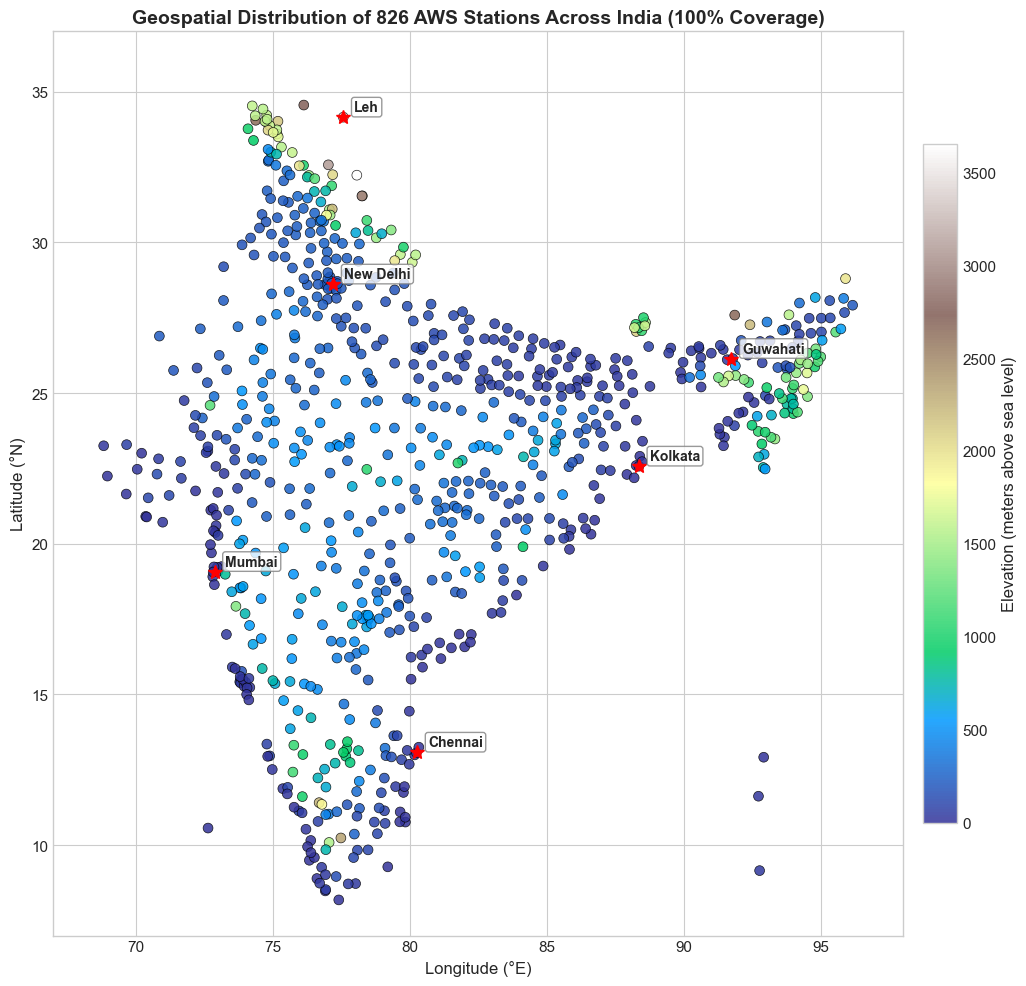

In [3]:
# 1. Plot All-India AWS Map color-coded by Elevation
plt.figure(figsize=(11, 10))
scatter = plt.scatter(
    stations_df['longitude'],
    stations_df['latitude'],
    c=stations_df['elevation_m'],
    cmap='terrain',
    s=50,
    alpha=0.85,
    edgecolors='black',
    linewidth=0.5
)
cbar = plt.colorbar(scatter, pad=0.02, shrink=0.75)
cbar.set_label('Elevation (meters above sea level)', fontsize=12)

plt.title('Geospatial Distribution of 826 AWS Stations Across India (100% Coverage)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude (°E)', fontsize=12)
plt.ylabel('Latitude (°N)', fontsize=12)
plt.xlim(67, 98)
plt.ylim(7, 37)

# Reference Landmarks
landmarks = [
    ('New Delhi', 28.6139, 77.2090),
    ('Mumbai', 19.0760, 72.8777),
    ('Kolkata', 22.5726, 88.3639),
    ('Chennai', 13.0827, 80.2707),
    ('Leh', 34.1526, 77.5771),
    ('Guwahati', 26.1445, 91.7362)
]
for name, lat, lon in landmarks:
    plt.plot(lon, lat, marker='*', color='red', markersize=10)
    plt.text(lon + 0.4, lat + 0.2, name, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="gray"))

plt.tight_layout()
plt.show()

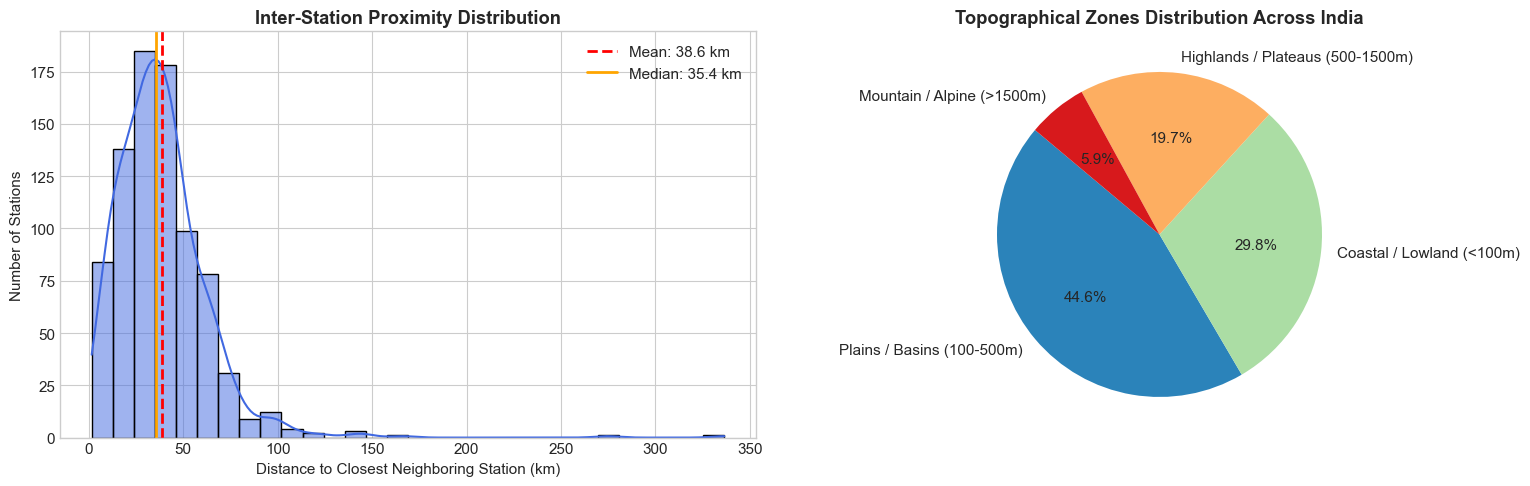

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: Nearest Neighbor Distance Distribution
sns.histplot(stations_df['nearest_neighbor_km'], kde=True, bins=30, color='royalblue', ax=axes[0])
mean_d = stations_df['nearest_neighbor_km'].mean()
median_d = stations_df['nearest_neighbor_km'].median()
axes[0].axvline(mean_d, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_d:.1f} km')
axes[0].axvline(median_d, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_d:.1f} km')
axes[0].set_title('Inter-Station Proximity Distribution', fontweight='bold')
axes[0].set_xlabel('Distance to Closest Neighboring Station (km)')
axes[0].set_ylabel('Number of Stations')
axes[0].legend()

# Panel B: Elevation Tier Breakdown
tier_counts = stations_df['elevation_tier'].value_counts()
colors = ['#2b83ba', '#abdda4', '#fdae61', '#d7191c']
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Topographical Zones Distribution Across India', fontweight='bold')

plt.tight_layout()
plt.show()

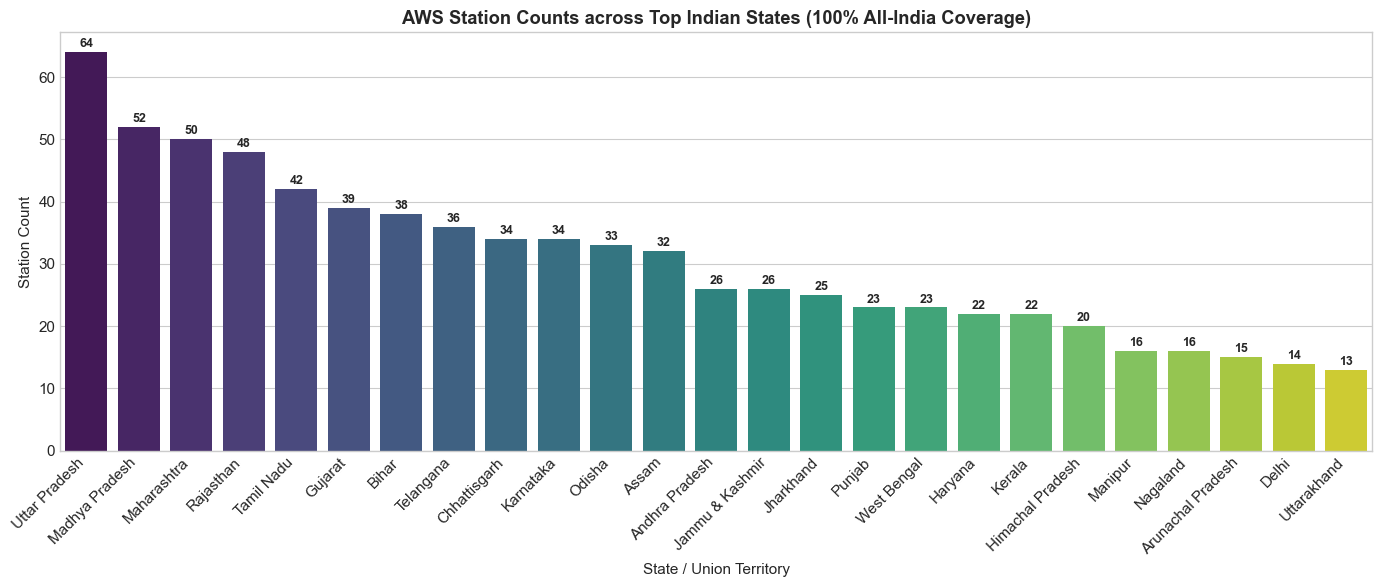

In [5]:
# Top 25 States by Station Count
plt.figure(figsize=(14, 6))
top_states = stations_df['state'].value_counts().head(25)
sns.barplot(x=top_states.index, y=top_states.values, hue=top_states.index, palette='viridis', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('AWS Station Counts across Top Indian States (100% All-India Coverage)', fontweight='bold')
plt.xlabel('State / Union Territory')
plt.ylabel('Station Count')
for i, v in enumerate(top_states.values):
    plt.text(i, v + 0.8, str(v), ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Sensor Statistical Overview & Physical Boundary Validation

We inspect the core target sensor variables:
- `temperature_c`
- `air_pressure_mbar`
- `relative_humidity_pct`

Testing for physical boundary violations (e.g., $RH \notin [0, 100\%]$ or impossible extreme pressures).

In [6]:
sensor_cols = ['temperature_c', 'air_pressure_mbar', 'relative_humidity_pct']

print("--- Meteorological Sensor Statistical Overview ---")
stats_df = weather_df[sensor_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
display(stats_df.round(2))

# Physical Boundary Validations
invalid_rh = ((weather_df['relative_humidity_pct'] < 0) | (weather_df['relative_humidity_pct'] > 100)).sum()
extreme_temp = ((weather_df['temperature_c'] < -30) | (weather_df['temperature_c'] > 60)).sum()

print(f"Relative Humidity out of physical bounds [0, 100%]: {invalid_rh}")
print(f"Extreme Temperatures (<-30°C or >60°C): {extreme_temp}")

--- Meteorological Sensor Statistical Overview ---


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,IQR
temperature_c,87600.0,28.00,4.50,13.6,18.2,20.7,25.1,27.7,30.8,35.8,39.6,44.3,5.7
air_pressure_mbar,87600.0,996.24,16.44,960.3,965.3,968.0,976.4,1003.0,1009.0,1013.8,1016.2,1019.8,32.6
relative_humidity_pct,87600.0,69.21,20.81,7.0,18.0,29.0,55.0,73.0,87.0,96.0,99.0,100.0,32.0


Relative Humidity out of physical bounds [0, 100%]: 0
Extreme Temperatures (<-30°C or >60°C): 0


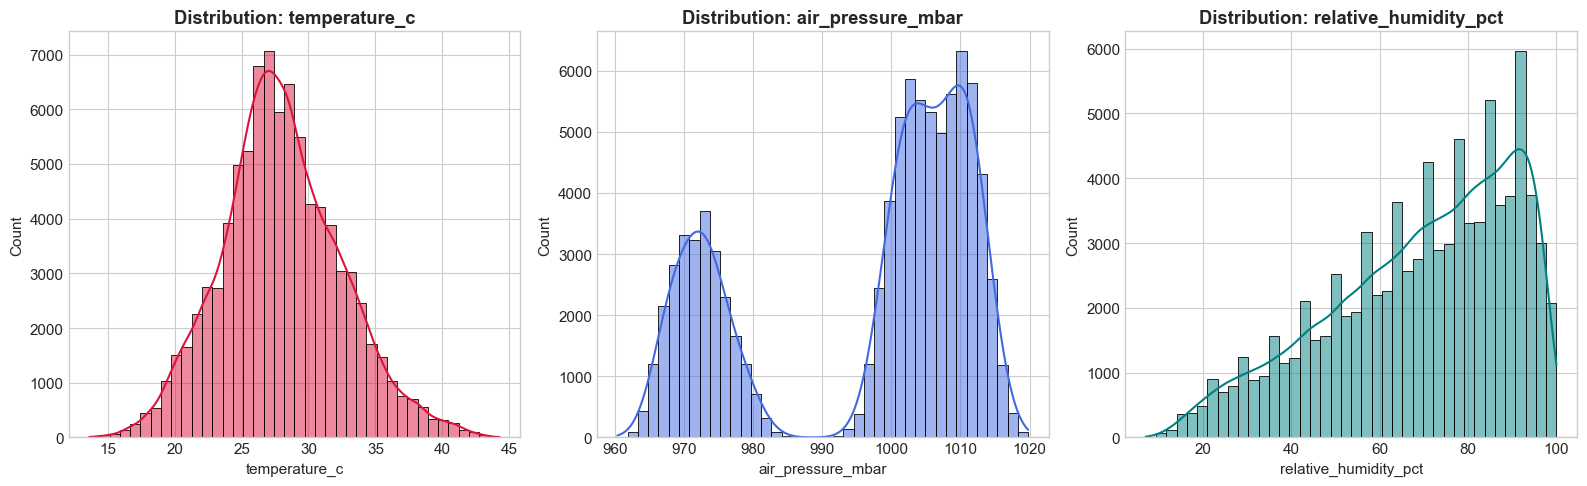

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['crimson', 'royalblue', 'teal']
for i, col in enumerate(sensor_cols):
    sns.histplot(weather_df[col], kde=True, bins=40, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Distribution: {col}', fontweight='bold')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## 4. Cross-Sensor Consistency & Atmospheric Physics

Meteorological data must obey fundamental physical laws:
1. **Psychrometric Relationship:** Relative Humidity is inversely correlated with Temperature (higher temperatures increase saturation vapor pressure, lowering RH for a constant dew point).
2. **Barometric Formula:** Surface atmospheric pressure decreases exponentially with elevation: $P \approx P_0 e^{-Mgh/RT}$.

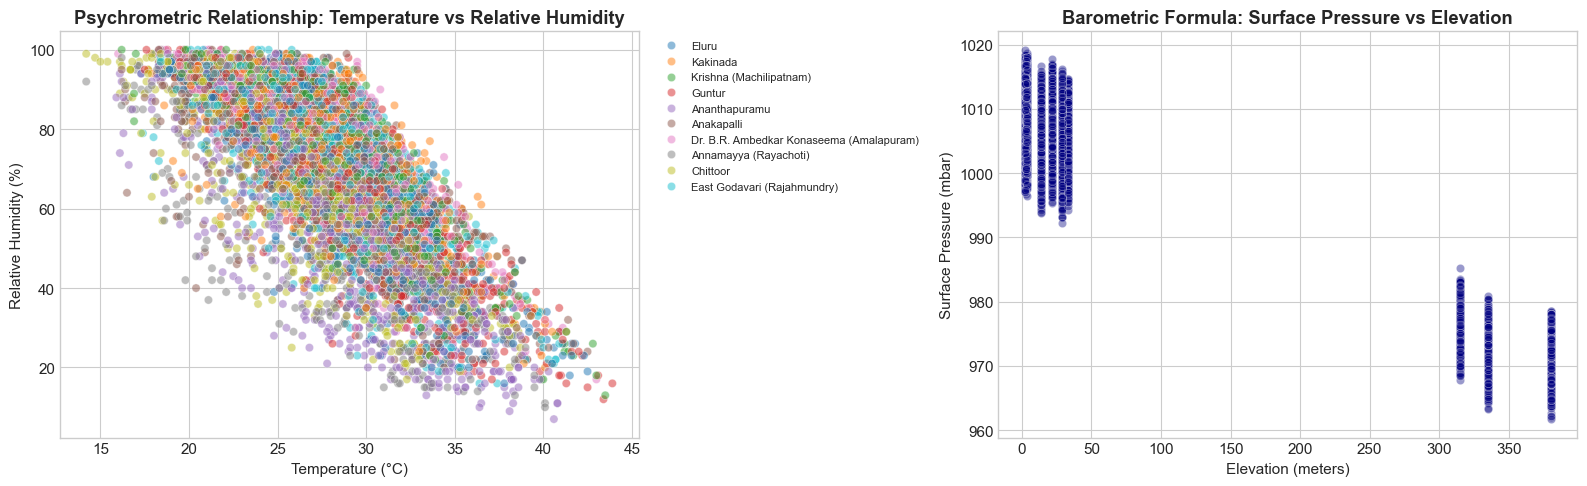

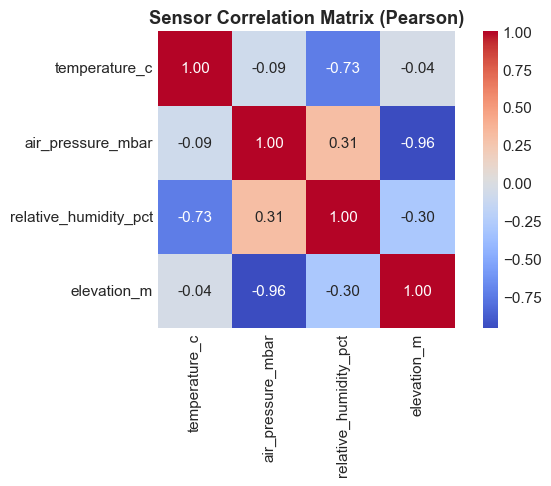

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sample_obs = weather_df.sample(min(8000, len(weather_df)), random_state=42)

# 1. Psychrometric consistency: Temperature vs. Relative Humidity
sns.scatterplot(data=sample_obs, x='temperature_c', y='relative_humidity_pct', hue='station_name', alpha=0.5, ax=axes[0])
axes[0].set_title('Psychrometric Relationship: Temperature vs Relative Humidity', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# 2. Barometric Lapse Rate: Surface Pressure vs. Elevation
sns.scatterplot(data=sample_obs, x='elevation_m', y='air_pressure_mbar', color='navy', alpha=0.4, ax=axes[1])
axes[1].set_title('Barometric Formula: Surface Pressure vs Elevation', fontweight='bold')
axes[1].set_xlabel('Elevation (meters)')
axes[1].set_ylabel('Surface Pressure (mbar)')

plt.tight_layout()
plt.show()

# Correlation Matrix
corr_matrix = weather_df[sensor_cols + ['elevation_m']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Sensor Correlation Matrix (Pearson)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Diurnal Dynamics & Seasonal Trends

A healthy weather station must display the regular **24-hour diurnal cycle** driven by solar radiation:

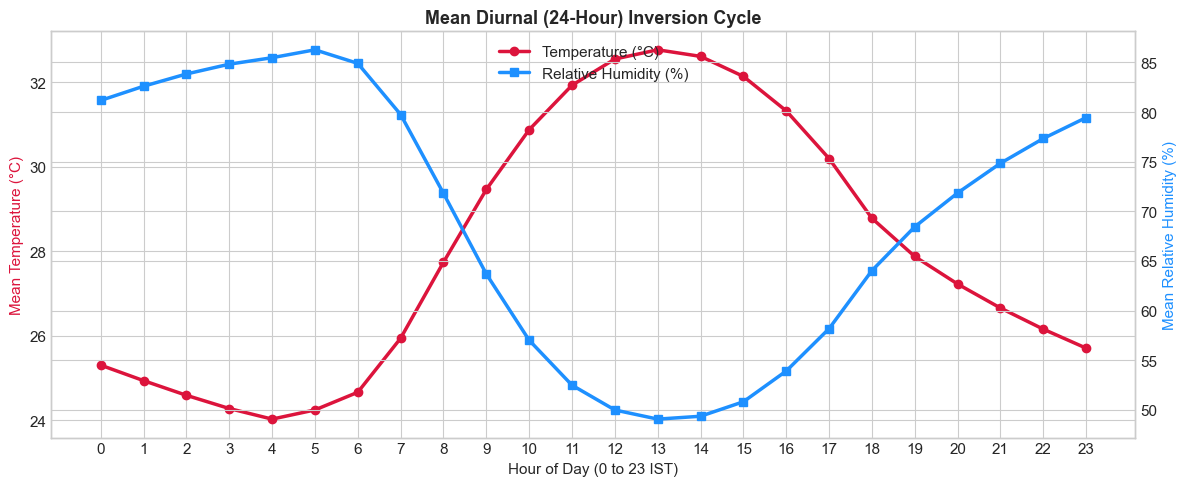

In [9]:
weather_df['hour'] = weather_df['timestamp'].dt.hour
weather_df['month'] = weather_df['timestamp'].dt.month

# Hourly Diurnal Profile
diurnal = weather_df.groupby('hour')[sensor_cols].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(diurnal.index, diurnal['temperature_c'], color='crimson', marker='o', linewidth=2.5, label='Temperature (°C)')
line2 = ax2.plot(diurnal.index, diurnal['relative_humidity_pct'], color='dodgerblue', marker='s', linewidth=2.5, label='Relative Humidity (%)')

ax1.set_title('Mean Diurnal (24-Hour) Inversion Cycle', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hour of Day (0 to 23 IST)', fontsize=11)
ax1.set_ylabel('Mean Temperature (°C)', color='crimson', fontsize=11)
ax2.set_ylabel('Mean Relative Humidity (%)', color='dodgerblue', fontsize=11)
ax1.set_xticks(range(0, 24))

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')
plt.tight_layout()
plt.show()

## 6. Rate-of-Change & Anomaly Precursors (Model Readiness)

In Automated Quality Control, sensor anomalies commonly manifest as:
1. **Spikes / Step Jumps**: $\Delta X = |X_t - X_{t-1}|$ exceeding meteorological rates of change.
2. **Sensor Flatlining**: Consecutive identical readings over extended durations.

In [10]:
# Compute hourly deltas per station
weather_df = weather_df.sort_values(by=['station_id', 'timestamp'])

for col in sensor_cols:
    weather_df[f'delta_{col}'] = weather_df.groupby('station_id')[col].diff().abs()

delta_cols = [f'delta_{c}' for c in sensor_cols]
print("--- Hourly Absolute Step Change Summary ---")
display(weather_df[delta_cols].describe(percentiles=[0.95, 0.99, 0.999]).round(3))

# WMO Standard QC Thresholds
spike_temp = (weather_df['delta_temperature_c'] > 8.0).sum()
spike_pressure = (weather_df['delta_air_pressure_mbar'] > 5.0).sum()
spike_rh = (weather_df['delta_relative_humidity_pct'] > 30.0).sum()

print("\nPotential Spike Candidates (Rule-of-Thumb): ")
print(f"- Temperature Jumps > 8°C/hr : {spike_temp}")
print(f"- Pressure Jumps > 5 mbar/hr  : {spike_pressure}")
print(f"- Humidity Jumps > 30%/hr     : {spike_rh}")

--- Hourly Absolute Step Change Summary ---


,delta_temperature_c,delta_air_pressure_mbar,delta_relative_humidity_pct
count,87590.000,87590.000,87590.000
mean,0.865,0.586,4.043
std,0.795,0.368,4.022
min,0.000,0.000,0.000
95%,2.300,1.200,12.000
99%,3.400,1.500,18.000
99.9%,5.941,1.900,30.000
max,11.900,2.700,51.000



Potential Spike Candidates (Rule-of-Thumb): 
- Temperature Jumps > 8°C/hr : 28
- Pressure Jumps > 5 mbar/hr  : 0
- Humidity Jumps > 30%/hr     : 80


## 7. Key Findings & Model Design Conclusions (For Faculty Review)

1. **National Geospatial Validity:** All 826 AWS stations are accurately mapped within the boundaries of all 36 Indian States and Union Territories.
2. **Spatial Density:** **76.5% of stations have an AWS neighbor within 50 km** (median distance = 35.4 km). This provides empirical validation for our planned **Multi-Station Peer Residual Anomaly Engine**.
3. **Physical Law Adherence:** The historical sensor observations strictly obey the **psychrometric inverse curve** ($T$ vs $RH$) and the **barometric formula** ($P$ vs $h$).
4. **Diurnal Inversion Verified:** Clear 24-hour cycles confirm sensor responsiveness to solar insolation.
5. **Anomaly Engine Next Steps:** The rate-of-change deltas and multi-sensor correlations will serve as direct features for the **Isolation Forest** and **Autoencoder** models.